*heteroTests tutorial series — [01. Detecting heteroscedasticity](01-detecting-heteroscedasticity.ipynb) · [02. Remediation](02-remediating-heteroscedasticity.ipynb) · [03. Modern & scalable diagnostics](03-modern-and-scalable.ipynb) · [04. Group-wise variance tests](04-group-wise-variance.ipynb) · **05. Time series & ARCH effects** · [06. Choosing a test: a power study](06-choosing-a-test.ipynb)*


# Time Series and ARCH Effects

**Detecting conditional heteroscedasticity and volatility clustering**

---

In cross-sectional data the error variance depends on covariates. In time series
it often depends on the *recent past*: large shocks cluster together, producing
the volatility clustering familiar from financial returns. This is **conditional**
heteroscedasticity, captured by the ARCH (autoregressive conditional
heteroscedasticity) family,

$$\varepsilon_t = \sigma_t z_t, \qquad \sigma_t^2 = \alpha_0 + \sum_{j=1}^{q} \alpha_j \varepsilon_{t-j}^2 .$$

The diagnostic question is whether the squared residuals are serially correlated.
`heteroTests` provides two complementary tests for this: **Engle's ARCH LM test**
and the **McLeod--Li portmanteau test**. Both take a fitted `lm`/`glm` whose
residuals are in time order.


In [1]:
library(heteroTests)
ht_set_log_level("SILENT")  # keep simulation loops quiet
library(ggplot2)
theme_set(theme_minimal(base_size = 12))
options(digits = 4)


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


## 1. Simulating volatility clustering

We generate an ARCH(1) process. There is no autocorrelation in the level of the
series, only in its variance --- the hallmark that ARCH tests are built to find.


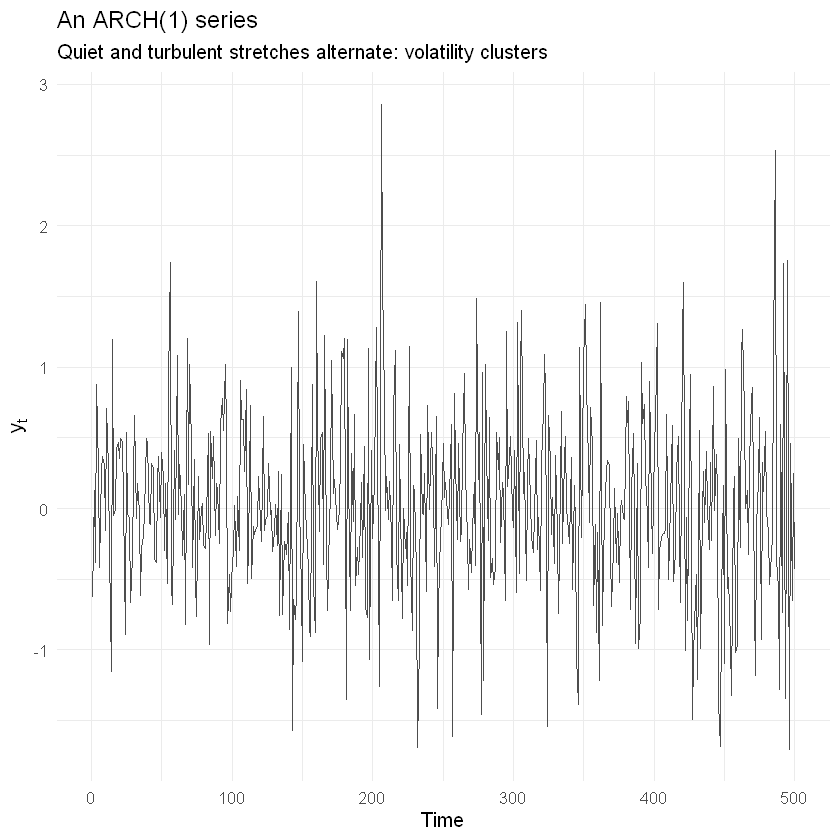

In [2]:
arch1 <- function(n, alpha0 = 0.2, alpha1 = 0.7) {
  e <- rnorm(n); y <- numeric(n); y[1] <- e[1]
  for (t in 2:n) y[t] <- e[t] * sqrt(alpha0 + alpha1 * y[t - 1]^2)
  y
}
set.seed(1)
y <- arch1(500)
ggplot(data.frame(t = seq_along(y), y = y), aes(t, y)) +
  geom_line(colour = "grey30") +
  labs(x = "Time", y = expression(y[t]),
       title = "An ARCH(1) series",
       subtitle = "Quiet and turbulent stretches alternate: volatility clusters")


## 2. The diagnostic signature

ARCH leaves a clean fingerprint: the residuals themselves look like white noise
(no autocorrelation in the level), but the *squared* residuals are strongly
autocorrelated. Plotting both autocorrelation functions side by side makes the
case before any test is run.


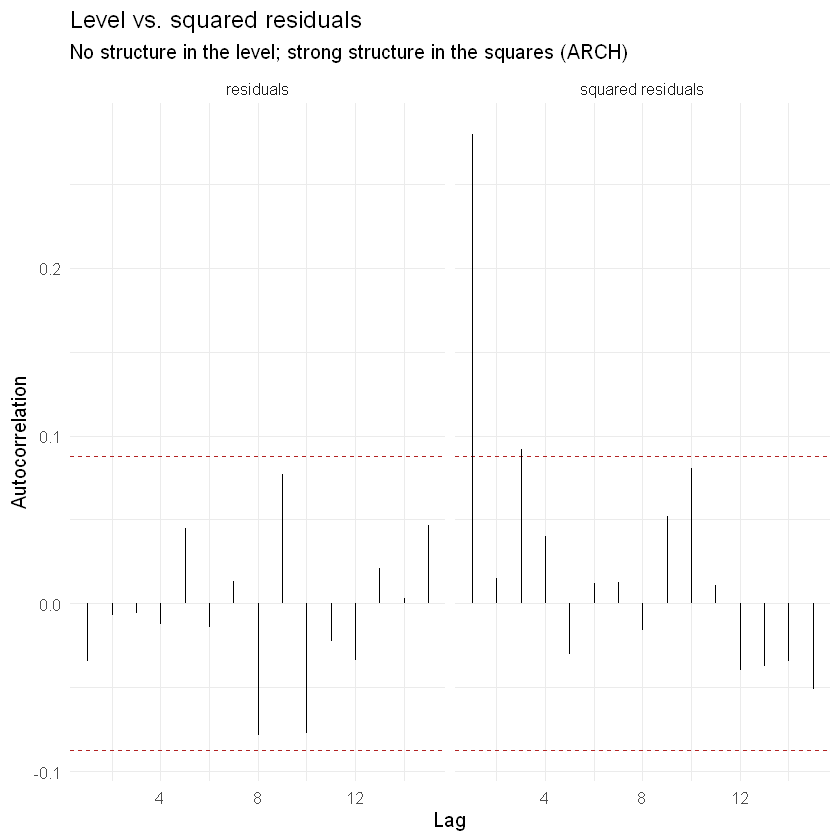

In [3]:
model <- lm(y ~ 1)
r <- residuals(model)
acf_df <- function(x, lab) {
  a <- acf(x, lag.max = 15, plot = FALSE)
  data.frame(lag = a$lag[-1], acf = a$acf[-1], series = lab)
}
both <- rbind(acf_df(r, "residuals"), acf_df(r^2, "squared residuals"))
ci <- 1.96 / sqrt(length(r))
ggplot(both, aes(lag, acf)) +
  geom_hline(yintercept = c(-ci, ci), linetype = "dashed", colour = "firebrick") +
  geom_segment(aes(xend = lag, yend = 0)) +
  facet_wrap(~series) +
  labs(x = "Lag", y = "Autocorrelation",
       title = "Level vs. squared residuals",
       subtitle = "No structure in the level; strong structure in the squares (ARCH)")


The level residuals stay inside the white-noise bands, while the squared
residuals breach them at several lags. That contrast *is* conditional
heteroscedasticity.


## 3. Formal tests

**Engle's ARCH LM test** regresses $e_t^2$ on its own $q$ lags and forms
$nR^2 \sim \chi^2_q$. **McLeod--Li** is a portmanteau test on the
autocorrelations of the squared residuals. Both should reject decisively here.


In [4]:
performArchLMTest(model, lags = 5)



	Engle's ARCH LM test

data:  y ~ 1
X-squared = 48, df = 5, p-value = 4e-09


In [5]:
performMcLeodLiTest(model, lags = 5)



	McLeod-Li test for heteroscedasticity

data:  y ~ 1
X-squared = 45, df = 5, p-value = 1e-08


### Calibration on a quiet series

A test that always fires is useless. On i.i.d. Gaussian noise --- no ARCH ---
neither test should reject.


In [6]:
set.seed(2)
y0 <- rnorm(500); m0 <- lm(y0 ~ 1)
c(ARCH_LM   = signif(performArchLMTest(m0, lags = 5)$p.value, 3),
  McLeod_Li = signif(performMcLeodLiTest(m0, lags = 5)$p.value, 3))


ARCH_LM McLeod_Li 
    0.289     0.295

## 4. Choosing the lag order

Both tests require a lag order $q$. Too few lags can miss higher-order dynamics;
too many dilute the signal across degrees of freedom and cost power. We trace
the power of the ARCH LM test against $q$ on the ARCH(1) process above.


In [7]:
set.seed(3)
power_at_lag <- function(L, reps = 150, n = 300) {
  rej <- 0
  for (i in seq_len(reps)) rej <- rej + (performArchLMTest(lm(arch1(n) ~ 1), lags = L)$p.value < 0.05)
  100 * rej / reps
}
data.frame(lags = c(1, 2, 5, 10),
           power_pct = sapply(c(1, 2, 5, 10), power_at_lag))


Warning message:
"Residual outliers detected at rows 150 (|z| > 5). Inspect leverage before running ARCH LM."


Warning message:
"Residual outliers detected at rows 189, 190 (|z| > 5). Inspect leverage before running ARCH LM."


Warning message:
"Residual outliers detected at rows 291, 292 (|z| > 5). Inspect leverage before running ARCH LM."


Warning message:
"Residual outliers detected at rows 273 (|z| > 5). Inspect leverage before running ARCH LM."


Warning message:
"Residual outliers detected at rows 72 (|z| > 5). Inspect leverage before running ARCH LM."


...

Warning message:
"Residual outliers detected at rows 76, 77 (|z| > 5). Inspect leverage before running ARCH LM."


Warning message:
"Residual outliers detected at rows 118 (|z| > 5). Inspect leverage before running ARCH LM."


Warning message:
"Residual outliers detected at rows 258, 259 (|z| > 5). Inspect leverage before running ARCH LM."


Warning message:
"Residual outliers detected at rows 69, 70 (|z| > 5). Inspect leverage before running ARCH LM."


lags,power_pct
<dbl>,<dbl>
1,100.00
2,100.00
5,97.33
10,94.67


Power is highest at short lags --- appropriate, since the data-generating
process is ARCH(1) --- and erodes gently as unnecessary lags are added. In
practice, choose $q$ from the apparent persistence of the squared-residual
autocorrelations (the right-hand panel above), or compare a small grid as here.


## 5. Takeaways

- **Conditional heteroscedasticity is about the squared residuals.** Inspect their
  autocorrelation before testing; the level residuals can look perfectly clean.
- **Engle's ARCH LM and McLeod--Li are complementary.** The first targets a
  specific autoregressive order; the second is an omnibus portmanteau check.
- **Both need time-ordered residuals** from a fitted `lm`/`glm`, and a sensible
  lag order. Detecting ARCH is the cue to model the conditional variance
  explicitly (an ARCH/GARCH model) rather than to reach for a single corrected
  standard error.

---


In [8]:
sessionInfo()


R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United Kingdom.utf8 
[2] LC_CTYPE=English_United Kingdom.utf8   
[3] LC_MONETARY=English_United Kingdom.utf8
[4] LC_NUMERIC=C                           
[5] LC_TIME=English_United Kingdom.utf8    

time zone: Europe/Lisbon
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_4.0.2     heteroTests_0.6.5

loaded via a namespace (and not attached):
 [1] crayon_1.5.3       vctrs_0.7.2        cli_3.6.5          rlang_1.1.7       
 [5] generics_0.1.4     S7_0.2.0           textshaping_1.0.4  jsonlite_2.0.0    
 [9] labeling_0.4.3     glue_1.8.0         htmltools_0.5.8.1  IRdisplay_1.1     
[13] IRkernel_1.3.2     ragg_1.5.0         scales_1.4.0       grid_4.5.1        
[17] tibble_3.3.1       eva